##  What is a Tensor?

A **tensor** is a **multi-dimensional array** (generalization of scalars, vectors, matrices). ([PyTorch Documentation][1])

Tensors are the fundamental building block of machine learning.
Their job is to represent data in a numerical way.

For example, you could represent an image as a tensor with shape `[3, 224, 224]` which would mean `[colour_channels, height, width]`, as in the image has 3 colour channels `(red, green, blue)`, a height of 224 pixels and a width of 224 pixels.

### Simple mapping:

* 0D → Scalar → `5`
* 1D → Vector → `[1,2,3]`
* 2D → Matrix → `[[1,2],[3,4]]`
* nD → Tensor → used in deep learning

 Key properties:

* **shape** → dimensions
* **dtype** → data type
* **device** → CPU / GPU ([PyTorch Documentation][2])

---


In [ ]:
import torch
import matplotlib.pyplot as plt

```python
torch.tensor(data, dtype, device, requires_grad, pin_memory)
```
---

###  `data`

**Info:** Input data used to create the tensor; defines values and initial shape.
**Possible values:**

* Python lists/tuples → `[1,2,3]`, `[[1,2],[3,4]]`
* NumPy arrays → `np.array([...])`
* Scalars → `5`, `3.14`
* Existing tensors

---

###  `dtype`

**Info:** Specifies the **data type (numerical precision/format)** of tensor elements.
**Possible values:**

* `torch.float32` (default for floats)
* `torch.float64`
* `torch.int32`, `torch.int64`
* `torch.bool`
* `torch.uint8`

---

###  `device`

**Info:** Determines where the tensor is stored and computed (hardware allocation).
**Possible values:**

* `'cpu'`
* `'cuda'` (GPU, if available)
* `'cuda:0'`, `'cuda:1'` (specific GPU index)

---

###  `requires_grad`

**Info:** Enables **automatic gradient tracking** for backpropagation (used in training).
**Possible values:**

* `True` → track gradients
* `False` (default) → no tracking

---

###  `pin_memory`

**Info:** Allocates tensor in **pinned (page-locked) memory** for faster CPU → GPU transfer.
**Possible values:**

* `True` → faster transfer (used in DataLoader pipelines)
* `False` (default)

---

####  Key Insight

This function acts as a **tensor constructor with configurable attributes**, allowing control over:

* memory placement
* numerical representation
* gradient behavior

---

####  Summary

* **dtype** → numerical data representation
* **device allocation** → hardware placement of tensor
* **gradient tracking** → storing derivatives for optimization
* **pinned memory** → optimized memory for faster data transfer

---


In [3]:
type(torch.tensor([23,4,3]))

torch.Tensor

##  1. Create Tensor from Data (Most Basic)

```python
import torch

t = torch.tensor([1, 2, 3])
t2 = torch.tensor([[1, 2], [3, 4]])
```

✔ Always copies data (important detail) ([PyTorch Documentation][1])

---

#### Scaler

In [4]:
scaler = torch.tensor(2)
scaler, scaler.ndim, type(scaler), scaler.item(), type(scaler.item())

(tensor(2), 0, torch.Tensor, 2, int)

#### Vector

In [5]:
vector = torch.tensor([1,3,4,5])
vector, vector.ndim, vector.shape, type(vector), vector[1].item()

# vector.item() ---> ERROR becuase only one element can be converted to number not a bunch of numbers

(tensor([1, 3, 4, 5]), 1, torch.Size([4]), torch.Tensor, 3)

#### Matrix

In [6]:
MATRIX = torch.tensor([[1,3],
                       [4,6]])
MATRIX, MATRIX.ndim, MATRIX.shape, type(MATRIX), MATRIX[1][1].item()

(tensor([[1, 3],
         [4, 6]]),
 2,
 torch.Size([2, 2]),
 torch.Tensor,
 6)

##  2. Empty Tensor (Uninitialized)

```python
torch.empty(2, 3)
```

 Memory allocated but values = garbage
✔ Useful for **performance optimization**

---


In [7]:
empty_tensor = torch.empty(2,2,3, dtype=int)
empty_tensor, empty_tensor.shape, empty_tensor.ndim, empty_tensor.type(), type(empty_tensor), empty_tensor.device

(tensor([[[2208238272672,             0,             0],
          [            0,             0,             0]],
 
         [[            0,             0,             0],
          [            0,             0,             0]]]),
 torch.Size([2, 2, 3]),
 3,
 'torch.LongTensor',
 torch.Tensor,
 device(type='cpu'))

---

# HOW TO UNDERSTAND TENSOR

#### ***Totally same as NumPy Arrays***

**shape = [x, y, z, a, b, d, ..., w, r, c]**

```
c = number of columns
r = number of rows
w = w times c x r
d = d times  ..., w, r, c
b = b times d, ..., w, r, c
.
.
.
x = x times y, z, a, b, d, ..., w, r, c
```
~~~
Always have [] -> container brackets
then x number of []
then y number of [] inside each x number of []
then z number of [] inside each y number of []
..
...
....
then r number of rows each in [] x c number of columns as a matrix insided each w number of []
~~~

---

### DataType of tensors
The default dtype for tensors is torch.float32 i.e. float except when data given to create tensors are all integers

**```torch.Tensor``` itself is an alias of FloatTensor (float32)**

You can change default using:
```torch.set_default_dtype(torch.float64)```
* Can only set for float dtypes*

#### Why float32 is default?
* Balanced precision vs performance
* Faster on GPUs
* Lower memory than float64

This is an important optimization trade-off in deep learning.


---

#  3. Zeros Tensor

```python
torch.zeros(2, 3)
```

✔ All values = 0 ([PyTorch Wiki][3])

---

In [8]:
zero_tensor = torch.zeros(2,5, dtype=int)
zero_tensor, zero_tensor.dtype, 

(tensor([[0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0]]),
 torch.int64)

#  4. Ones Tensor

```python
torch.ones(2, 3)
```

✔ All values = 1 ([Codecademy][4])

---

In [9]:
#Ones Tensor
ones_tensor = torch.ones(3,4)
ones_tensor, ones_tensor.dtype


(tensor([[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]]),
 torch.float32)


#  5. Random Tensor (Uniform Distribution)

```python
torch.rand(2, 3)
```

✔ Values between `[0,1)` ([PyTorch Wiki][5])

---

In [10]:
random_tensor = torch.rand(3,4)
random_tensor, random_tensor.shape, random_tensor.size, random_tensor.dtype, random_tensor.ndim

'''
🔴 Why this error occurs?
torch.rand(3,4, dtype=torch.int32)

👉 Error:

"check_uniform_bounds" not implemented for 'Int'
✔ Reason:
    * torch.rand() generates values from a uniform distribution → continuous values between [0, 1)
    * This operation is defined only for floating-point tensors, not integers (pytorch.org
)

👉 Integer tensors cannot represent continuous random values
'''

'\n🔴 Why this error occurs?\ntorch.rand(3,4, dtype=torch.int32)\n\n👉 Error:\n\n"check_uniform_bounds" not implemented for \'Int\'\n✔ Reason:\n    * torch.rand() generates values from a uniform distribution → continuous values between [0, 1)\n    * This operation is defined only for floating-point tensors, not integers (pytorch.org\n)\n\n👉 Integer tensors cannot represent continuous random values\n'

#### Syntax for random generation of tensors

```python
torch.rand(size)        # Uniform distribution [0, 1)
torch.randn(size)       # Normal distribution (mean=0, std=1)
torch.randint(low, high, size)  # Integer values in [low, high)
```

## Why random tensor are important
##### Random tesnors are importatn because the awy many nerual networks learn is that they start with tensors full of random numbers adn then adjust those random numbers to better represent the data

```
Start with random number 
 -> 
look at data
 -> 
update random numbers
 -> 
look at data
 -> 
update random numbers
```


#  6. Random Normal (Gaussian Distribution)

```python
torch.randn(2, 3)
```

✔ Mean = 0, Std = 1
 Used heavily in neural networks

---

In [11]:
torch.randn(2,4)

tensor([[ 0.1133,  0.3399,  0.9508, -0.3802],
        [ 0.2495, -0.8149, -0.2699,  0.0030]])

### Diffrence between `torch.rand()` and `torch.randn()`
| Function        | Distribution Type              | Value Range |
| --------------- | ------------------------------ | ----------- |
| `torch.rand()`  | Uniform distribution           | `[0, 1)`    |
| `torch.randn()` | Normal (Gaussian) distribution | `(-∞, +∞)`  |


###  1. `torch.rand()`

**Definition:** Generates random numbers from a **uniform distribution**.

```python
torch.rand(2, 3)
```

#### ✔ Behavior:

* All values are between **0 and 1**
* Each value has **equal probability**

#### ✔ Example Output:

```
tensor([[0.12, 0.87, 0.45],
        [0.33, 0.91, 0.05]])
```

#### ✔ Usage:

* When you need **bounded random values**
* Probabilities, normalization tasks
* Initializing data in a controlled range

---

###  2. `torch.randn()`

**Definition:** Generates random numbers from a **normal (Gaussian) distribution**.

```python
torch.randn(2, 3)
```

#### ✔ Behavior:

* Mean = **0**
* Standard deviation = **1**
* Values can be **negative or positive**

#### ✔ Example Output:

```
tensor([[ 0.52, -1.34,  0.11],
        [-0.67,  2.10, -0.45]])
```

---

###  Visual/Conceptual Difference

* `rand()` → flat distribution (all values equally likely)
* `randn()` → bell curve (values near 0 are more frequent)

---

###  Real Usage in AI (Very Important)

#### ✔ `torch.randn()` (MOST IMPORTANT)

Used in:

* Neural network **weight initialization**
* Noise generation
* Deep learning models

👉 Reason:

* Centered around 0 → helps **gradient flow**
* Prevents bias in learning

---

#### ✔ `torch.rand()`

Used in:

* Data simulation
* Random sampling in fixed range
* Probabilistic tasks

---

###  Key Insight

👉 The difference is not just syntax — it’s a **statistical property difference**.

* `rand()` → **Uniform randomness**
* `randn()` → **Statistical randomness (Gaussian)**

---

###  Vocabulary Boost

* **Uniform distribution** → equal probability across interval
* **Gaussian distribution** → bell-shaped probability curve
* **Mean (μ)** → central value (0 in `randn`)
* **Standard deviation (σ)** → spread of data

---

In [12]:
## Craeating a random teansor wiht similar shape to an image tensor
'''
IMAGE SHAPE: (244, 244, 3) # Height, width, channel
'''
rnd_image1 = torch.rand((3, 10, 10))
print(rnd_image1)

rnd_image2 = torch.rand((244,244,3))
print(rnd_image2)

tensor([[[0.3697, 0.5081, 0.3903, 0.3726, 0.7525, 0.8610, 0.7424, 0.6699,
          0.9953, 0.9054],
         [0.2920, 0.9134, 0.7137, 0.0756, 0.0145, 0.4688, 0.8917, 0.9654,
          0.1147, 0.0639],
         [0.5421, 0.3211, 0.5272, 0.8975, 0.1638, 0.8463, 0.2665, 0.9266,
          0.0242, 0.9601],
         [0.4664, 0.2586, 0.1127, 0.8037, 0.1702, 0.3612, 0.0093, 0.7404,
          0.4255, 0.2316],
         [0.8804, 0.7799, 0.8512, 0.9708, 0.9665, 0.5492, 0.6988, 0.6461,
          0.9677, 0.8852],
         [0.3733, 0.2182, 0.2524, 0.3729, 0.6659, 0.5096, 0.3792, 0.5188,
          0.8644, 0.4244],
         [0.4772, 0.1663, 0.5995, 0.5338, 0.6758, 0.5687, 0.7632, 0.7087,
          0.5993, 0.8900],
         [0.3160, 0.8112, 0.7052, 0.8186, 0.5687, 0.8094, 0.2348, 0.0541,
          0.0302, 0.5953],
         [0.8622, 0.4178, 0.1036, 0.2008, 0.5256, 0.9315, 0.2829, 0.8337,
          0.1388, 0.1377],
         [0.7239, 0.6066, 0.8339, 0.8514, 0.3001, 0.1736, 0.6905, 0.9869,
          0.2413,

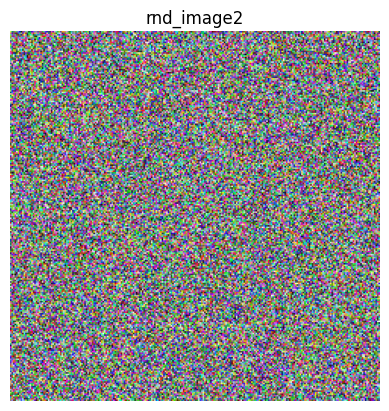

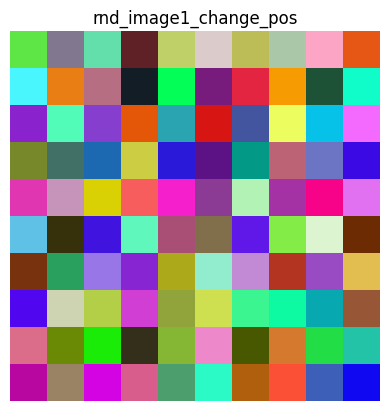

CPU times: total: 281 ms
Wall time: 299 ms


In [ ]:
%%time
plt.imshow(rnd_image2)
plt.Figure(figsize=(100, 100))
plt.title('rnd_image2')
plt.axis('off')
plt.show()

#shape = (3, 244, 244) -> (244, 244, 3)
#         0   1    2        0    1   2

rnd_image1_change_pos = rnd_image1.permute(1,2,0)
plt.imshow(rnd_image1_change_pos)
plt.Figure(figsize=(10, 10))
plt.title('rnd_image1_change_pos')
plt.axis('off')
plt.show()

The difference between these (rad_image) two tensors lies in the **position of the color channels**, a concept often referred to as "Channel First" vs. "Channel Last" ordering.

While both tensors contain the same total number of elements ($224 \times 224 \times 3 = 150,528$), they are structured differently in memory.

### 1. The Structural Difference

| Tensor | Order | Logic | Common Usage |
| :--- | :--- | :--- | :--- |
| `tensor1` | **$(C, H, W)$** | Channels, Height, Width | **PyTorch** default; standard for Deep Learning models. |
| `tensor2` | **$(H, W, C)$** | Height, Width, Channels | **OpenCV**, **Matplotlib**, and **TensorFlow** default. |

---

### 2. Which one is "Correct"?

In the context of **PyTorch** (since you are using `torch.rand`), **`random_image_size_tensor1` is the standard "correct" format.**

PyTorch's convolutional layers and vision models (like ResNet or EfficientNet) expect the input to be in the shape $(Batch, Channels, Height, Width)$. If you provide a tensor in $(H, W, C)$ format to a PyTorch model, it will likely throw a dimension mismatch error.

> **Note:** If you are planning to plot the image using `plt.imshow()`, you would actually need `tensor2` $(H, W, C)$. To convert from PyTorch format to Plotting format, you use `.permute()`:
> ```python
> Converts (3, 224, 224) -> (224, 224, 3)
> plt.imshow(tensor1.permute(1, 2, 0)) 
> ```

---

### Implementation Comparison

If you want to create a random tensor that exactly matches your specified `IMAGE SHAPE: (244, 244, 3)`, then `tensor2` is technically the "similar" shape. However, for functional deep learning code, you should almost always use the $(C, H, W)$ structure.

### Summary Table

| Feature | `tensor1` $(3, 244, 244)$ | `tensor2` $(244, 244, 3)$ |
| :--- | :--- | :--- |
| **Framework** | PyTorch (Standard) | TensorFlow / OpenCV / NumPy |
| **Model Compatibility** | Ready for Conv2d layers | Requires permutation |
| **Visualization** | Requires permutation to plot | Ready for `plt.imshow()` |

---

### Actionable Next Step
Would you like me to show you how to use `torch.permute` or `torch.unsqueeze` to prepare these tensors for a training loop or a specific model architecture?

---

##  7. Integer Random Tensor

```python
torch.randint(0, 10, (2, 3))
```

### torch.randint(range, (size))

✔ Values from 0 → 9

---

rand_int_tensor1 = tensor([5448,  193, 9404, 5475, 8297, 9413, 5329, 2348, 8965, 9402, 2030, 8442,
        8707, 8526, 8219, 8381, 1164, 7745, 1136, 8805])

tensor([[[134,  91,  57],
         [ 52, 206,  38],
         [ 92, 105, 168],
         [158,  80, 218]],

        [[120, 136, 222],
         [159,   2,   6],
         [127,  93, 152],
         [ 50,  82, 202]],

        [[ 54,  37, 163],
         [ 42, 146, 170],
         [223, 175, 222],
         [179,  74, 219]],

        [[144, 148, 217],
         [207,  82, 105],
         [ 65,  47, 112],
         [  0, 151,  10]]])
torch.Size([4, 4, 3])
<built-in method size of Tensor object at 0x00000279AA629D60>
torch.int64


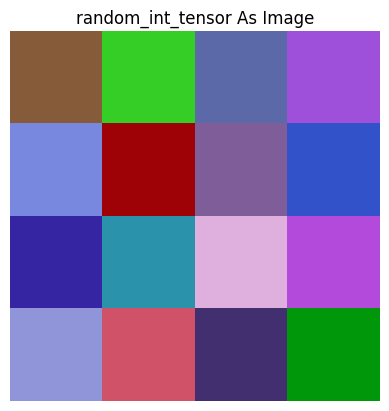

In [29]:
rand_int_tensor1 = torch.randint(0, 10000, (20,))
print(f'rand_int_tensor1 = {rand_int_tensor1}\n')
random_int_tensor = torch.randint(0, 225, size=(4,4,3))
print(f'{random_int_tensor}\n{random_int_tensor.shape}\n{random_int_tensor.size}\n{random_int_tensor.dtype}')
plt.imshow(random_int_tensor)
plt.title('random_int_tensor As Image')
plt.axis(False)
plt.show()

### ```Creating a range of tensors and tensor-like```

---

##  8. Range-Based Tensors

### arange (like range)

```python
torch.arange(0, 10, 2)
```

### linspace (fixed steps)

```python
torch.linspace(0, 1, steps=5)
```

---

In [15]:
# Using torch.arange()
## do not use tensor.range() -> will get removed in new version
x = torch.arange(0,10, dtype=torch.int32) # same as range - (start, end, step)
y = torch.arange(0,1000, 20, dtype=torch.float32)
x, y, x.dtype, type(x), y.dtype, type(y)

(tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=torch.int32),
 tensor([  0.,  20.,  40.,  60.,  80., 100., 120., 140., 160., 180., 200., 220.,
         240., 260., 280., 300., 320., 340., 360., 380., 400., 420., 440., 460.,
         480., 500., 520., 540., 560., 580., 600., 620., 640., 660., 680., 700.,
         720., 740., 760., 780., 800., 820., 840., 860., 880., 900., 920., 940.,
         960., 980.]),
 torch.int32,
 torch.Tensor,
 torch.float32,
 torch.Tensor)

In [16]:
# Creating tensor-like
ten_zeros = torch.zeros_like(input=x)
ones_like = torch.ones_like(input=y)
ten_zeros, ones_like


(tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=torch.int32),
 tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]))

#  9. Identity Matrix

```python
torch.eye(3)
```

✔ Diagonal = 1

---

#  10. Like Functions (Very Important)

Creates tensor based on another tensor:

```python
x = torch.rand(2,3)

torch.zeros_like(x)
torch.ones_like(x)
torch.rand_like(x)
```

 Maintains shape + dtype (important abstraction)

---

#  11. Custom Value Tensor

```python
torch.full((2,3), 7)
```

✔ All values = 7

---

#  12. From NumPy

```python
import numpy as np

arr = np.array([1,2,3])
torch.tensor(arr)
```

---

#  13. Tensor with Specific Properties

```python
torch.zeros(2,3, dtype=torch.float32, device='cpu', requires_grad=True)
```

 Key arguments:

* `dtype` → data type
* `device` → cpu / cuda
* `requires_grad` → for backpropagation

---

#  14. New Tensor from Existing Tensor

```python
x = torch.tensor([1,2,3])
x.new_zeros(2,3)
```

✔ Same dtype + device ([PyTorch Wiki][6])

---

#  15. Shape Specification (Important Pattern)

All creation functions follow:

```python
torch.function_name(size)
```

Example:

```python
torch.rand(3,4,5)
```

 This is called a **factory function pattern** ([PyTorch Documentation][7])

---

#  Summary (Very Important)

| Function           | Purpose                 |
| ------------------ | ----------------------- |
| `torch.tensor()`   | From data               |
| `torch.zeros()`    | All zeros               |
| `torch.ones()`     | All ones                |
| `torch.rand()`     | Uniform random          |
| `torch.randn()`    | Normal random           |
| `torch.randint()`  | Integer random          |
| `torch.arange()`   | Sequence                |
| `torch.linspace()` | Even spacing            |
| `torch.eye()`      | Identity                |
| `*_like()`         | Based on another tensor |

---

#  Vocabulary Boost

* **Tensor initialization** → creating tensors
* **Uniform distribution** → equal probability values
* **Gaussian distribution** → bell curve distribution
* **dtype** → numerical precision type
* **Device allocation** → CPU/GPU placement

---

##  Guidance (Important for you)

 First master:

1. `tensor()`
2. `zeros(), ones()`
3. `rand(), randn()`
4. `*_like()`

These are used in **90% of deep learning workflows**.

---